# Goal

- we want to dissect the images with streets in the middle from the rest
- we also only want one image per street


**Steps**
1. Split 360 degree image into 36 images (10° Offset per step and image width is ... °)
2. Get depth map per image
3. Calculate center of depth per image
4. Map the centers per image on polar coordinate system and cluster them
- create ring graph
- remove the largest edges
- until each edge is less than offset
- then remove clusters with less than (0.5 * width/offset) points
5. return images 


# Functions

In [ ]:
import numpy as np
from PIL import Image
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt
import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

In [ ]:
class StreetSegmentationModel:
    def __init__(self):
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
            print("Using Apple Silicon MPS (Metal) for acceleration.")
        else:
            self.device = torch.device("cpu")
            print("MPS not available. Falling back to CPU.")
        model_name = "nvidia/segformer-b2-finetuned-cityscapes-1024-1024"
        self.processor = SegformerImageProcessor.from_pretrained(model_name)
        self.model = SegformerForSemanticSegmentation.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()
        self.road_class_id = self.model.config.label2id.get('road', 0)

    def predict(self, image_input):
        """
        Takes an image path or a numpy array (BGR from cv2) and returns a binary road mask.
        """
        # Load image properly depending on input type
        if isinstance(image_input, str):
            image = Image.open(image_input).convert("RGB")
        else:
            # Assume it's an OpenCV numpy array (BGR) and convert to PIL (RGB)
            image = Image.fromarray(image_input[..., ::-1])

        # Prepare inputs and move them to the M3 GPU
        inputs = self.processor(images=image, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        # Run inference without calculating gradients
        with torch.no_grad():
            outputs = self.model(**inputs)
            
        # Segformer outputs are scaled down. We must interpolate them back to the original image dimensions.
        logits = outputs.logits
        upsampled_logits = torch.nn.functional.interpolate(
            logits,
            size=image.size[::-1], # PIL size is (width, height), interpolate expects (height, width)
            mode="bilinear",
            align_corners=False,
        )

        # Get the predicted class ID for each pixel
        predicted_classes = upsampled_logits.argmax(dim=1).squeeze(0)
        
        # Create a binary mask specifically for the "road" class (1 for road, 0 for everything else)
        # Move it back to the CPU memory and convert to a standard numpy array for the rest of your pipeline
        road_mask = (predicted_classes == self.road_class_id).cpu().numpy().astype(np.uint8)

        return road_mask

In [21]:
segmentation_model = StreetSegmentationModel()

Using Apple Silicon MPS (Metal) for acceleration.


/Users/lukasappel/Documents/HTW-Studium/Applied Artificial Intelligence/Projekt/AAIProject/.venv/lib/python3.13/site-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Loading weights: 100%|██████████| 380/380 [00:00<00:00, 2218.98it/s, Materializing param=segformer.encoder.patch_embeddings.3.proj.weight]            


In [27]:
import numpy as np
import cv2

def extract_perspective(equi_image, yaw, pitch, fov, width=600, height=600):
    """
    Extracts a planar perspective image from an equirectangular 360 panorama.
    
    Parameters:
    - equi_image: The original 360 image (numpy array from cv2.imread).
    - yaw: The horizontal viewing angle in degrees (-180 to 180).
    - pitch: The vertical viewing angle in degrees (0 is straight ahead).
    - fov: The horizontal Field of View in degrees (e.g., 90).
    - width, height: The dimensions of the output image.
    """
    # 1. Convert angles from degrees to radians
    yaw_rad = np.radians(yaw)
    pitch_rad = np.radians(pitch)
    fov_rad = np.radians(fov)
    
    equi_h, equi_w = equi_image.shape[:2]
    
    # 2. Calculate the focal length
    f = (width / 2.0) / np.tan(fov_rad / 2.0)
    
    # 3. Create a grid of x, y coordinates for the output image
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    
    # Center the coordinates around 0,0
    x = x - width / 2.0
    y = y - height / 2.0
    z = np.full_like(x, f) # Depth is the focal length
    
    # 4. Create 3D rays (stack x, y, z into a single array)
    rays = np.stack((x, y, z), axis=-1)
    
    # 5. Build rotation matrices for pitch (X-axis) and yaw (Y-axis)
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(pitch_rad), -np.sin(pitch_rad)],
        [0, np.sin(pitch_rad), np.cos(pitch_rad)]
    ])
    
    Ry = np.array([
        [np.cos(yaw_rad), 0, np.sin(yaw_rad)],
        [0, 1, 0],
        [-np.sin(yaw_rad), 0, np.cos(yaw_rad)]
    ])
    
    # Combine rotations (Yaw then Pitch)
    R = Ry @ Rx
    
    # 6. Apply rotation to our 3D rays
    # Flatten the rays for matrix multiplication, then reshape back
    rays_flat = rays.reshape(-1, 3)
    rotated_rays_flat = rays_flat @ R.T
    rotated_rays = rotated_rays_flat.reshape(height, width, 3)
    
    rx, ry, rz = rotated_rays[:, :, 0], rotated_rays[:, :, 1], rotated_rays[:, :, 2]
    
    # 7. Convert the rotated 3D rays into spherical coordinates (Longitude, Latitude)
    theta = np.arctan2(rx, rz)
    phi = np.arcsin(ry / np.linalg.norm(rotated_rays, axis=-1))
    
    # 8. Map the spherical coordinates to the equirectangular image pixels
    # Map theta [-pi, pi] to [0, equi_w - 1]
    map_x = (theta / (2 * np.pi) + 0.5) * (equi_w - 1)
    # Map phi [-pi/2, pi/2] to [0, equi_h - 1]
    map_y = (phi / np.pi + 0.5) * (equi_h - 1)
    
    # 9. Sample the pixels using OpenCV's remap function
    # BORDER_WRAP allows the image to seamlessly wrap around the 360-degree edges
    planar_image = cv2.remap(
        equi_image, 
        map_x.astype(np.float32), 
        map_y.astype(np.float32), 
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_WRAP 
    )
    
    return planar_image

In [84]:
import numpy as np
import cv2
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

import numpy as np
from scipy.signal import find_peaks

def find_circular_peaks(profile, distance, prominence):
    """
    Finds peaks in a circular 1D array.
    """
    W = len(profile)
    extended_profile = np.tile(profile, 3)
    extended_peaks, _ = find_peaks(
        extended_profile, 
        distance=distance, 
        prominence=prominence
    )
    valid_peaks = []
    for p in extended_peaks:
        if W <= p < 2 * W:
            valid_peaks.append(p % W)
    return np.array(valid_peaks)

def find_street_angles(road_mask):
    """
    Analyzes a binary road mask to find the yaw angles of street entrances.
    """
    H, W = road_mask.shape
    
    # find the 
    # road_mask is 1 for road, 0 otherwise. 
    # uses argmax to get the index of the highest mark in a column
    # if a clumn contains no 1, then its highest peak should be at the bottom
    road_pixels_exist = np.any(road_mask, axis=0)
    top_road_y = np.argmax(road_mask, axis=0)
    top_road_y[~road_pixels_exist] = H 
    
    # inverts the profile at the x-axis
    horizon_profile = H - top_road_y
    
    # smoothing of the curve
    smoothed_profile = gaussian_filter1d(horizon_profile, sigma=W/100)
    plt.plot(smoothed_profile)

    peaks, _ = find_circular_peaks(smoothed_profile, distance=W//16, prominence=H//200)
    
    # converts the coordinates back to angles
    yaws = [(x / W) * 360.0 - 180.0 for x in peaks]
    
    return yaws

def extract_street_views(equi_image, yaws):
    """
    Main pipeline to find streets and extract them.
    """
    extracted_images = []
    print(f"Found {len(yaws)} street entrances at angles: {yaws}")
    for yaw in yaws:
        planar_image = extract_perspective(equi_image, yaw=yaw, pitch=0, fov=90, width=600, height=600)
        extracted_images.append(planar_image)
        
    return extracted_images

In [70]:
import matplotlib.pyplot as plt
import cv2

def display_extracted_streets(images, yaws=None):
    """
    Displays a list of extracted street view images using matplotlib.
    Automatically converts OpenCV BGR format to Matplotlib RGB format.
    
    Parameters:
    - images: List of numpy arrays (the extracted 600x600 images).
    - yaws: Optional list of angles corresponding to the images for titles.
    """
    num_images = len(images)
    
    if num_images == 0:
        print("No images to display.")
        return

    # Create a dynamic figure size based on the number of extracted streets
    # 5 inches per image width, 5 inches tall
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    
    # If there's only one street found, matplotlib doesn't return an array of axes. 
    if num_images == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        
        # Display the image
        ax.imshow(img_rgb)
        ax.axis('off')
        if yaws and i < len(yaws):
            ax.set_title(f"Street View {i+1}\n(Angle: {yaws[i]:.1f}°)")
        else:
            ax.set_title(f"Street View {i+1}")
    plt.tight_layout()
    plt.show()

Found 4 street entrances at angles: [np.float64(-99.8125), np.float64(4.8125), np.float64(44.87499999999997), np.float64(119.1875)]


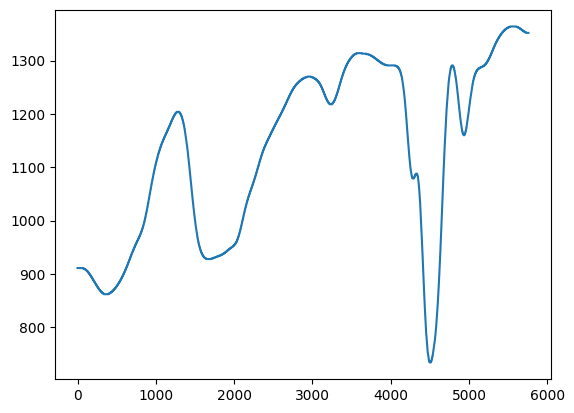

In [ ]:
panorama_path = "./streetview_panoramas/61efb4ce-cdf2-4160-aaf6-f5bca9c7e247.jpg"
img = cv2.imread(panorama_path)
road_mask = segmentation_model.predict(img) 
street_images = extract_street_views(img, road_mask)

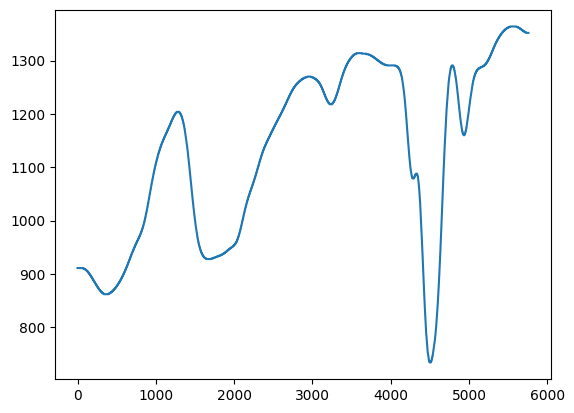

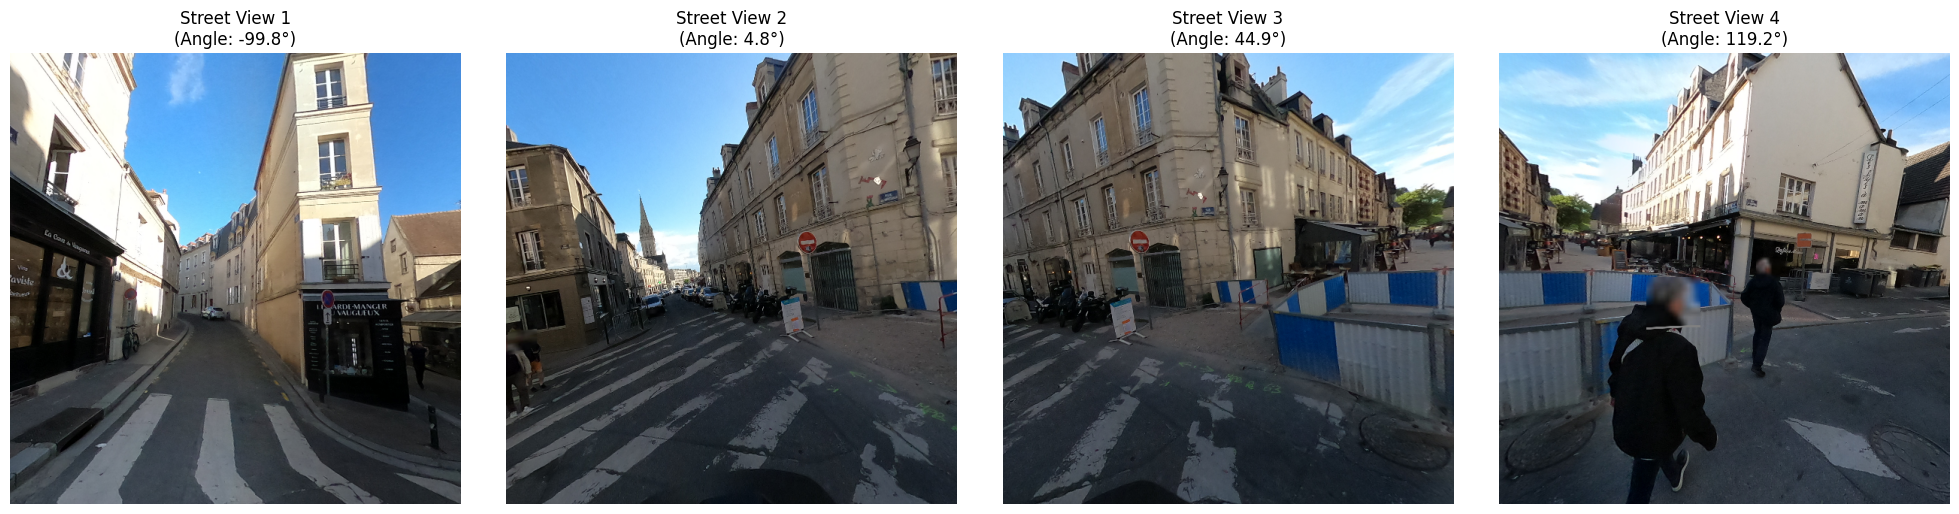

In [72]:
yaws = find_street_angles(road_mask)
display_extracted_streets(street_images, yaws)

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

class DepthEstimationModel:
    def __init__(self):
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
            print("Using Apple Silicon MPS for Depth Estimation.")
        else:
            self.device = torch.device("cpu")
        # Load the lightweight Depth Anything model
        model_name = "LiheYoung/depth-anything-small-hf"
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.model = AutoModelForDepthEstimation.from_pretrained(model_name).to(self.device)
        self.model.eval()

    def predict(self, image_input):
        """Generates a depth map from an image."""
        if isinstance(image_input, str):
            image = Image.open(image_input).convert("RGB")
        else:
            image = Image.fromarray(image_input[..., ::-1]) # Convert OpenCV BGR to RGB

        inputs = self.processor(images=image, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)
            predicted_depth = outputs.predicted_depth

        # Resize the output depth map to match the original image dimensions
        depth_map = torch.nn.functional.interpolate(
            predicted_depth.unsqueeze(1),
            size=image.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy()

        return depth_map

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

def compare_street_detection(image, road_mask, depth_map):
    """
    Plots the original image alongside the 1D profiles and detected peaks 
    from both the Semantic Segmentation and Depth Estimation approaches.
    """
    H, W = image.shape[:2]
    
    # ==========================================
    # 1. Calculate Segmentation Profile & Peaks
    # ==========================================
    # Clean the mask
    kernel = np.ones((15, 15), np.uint8) 
    clean_mask = cv2.morphologyEx(road_mask, cv2.MORPH_CLOSE, kernel)
    
    # Find horizon profile
    road_pixels_exist = np.any(clean_mask, axis=0)
    top_road_y = np.argmax(clean_mask, axis=0)
    top_road_y[~road_pixels_exist] = H 
    horizon_profile = H - top_road_y
    
    # Smooth and find peaks
    seg_profile = gaussian_filter1d(horizon_profile, sigma=W/200)
    seg_peaks = find_circular_peaks(seg_profile, distance=W//12, prominence=H//40)
    
    # ==========================================
    # 2. Calculate Depth Profile & Peaks
    # ==========================================
    # Crop to horizon band
    top_crop = int(H * 0.35)
    bottom_crop = int(H * 0.65)
    horizon_band = depth_map[top_crop:bottom_crop, :]
    
    # Average and invert
    column_depths = np.mean(horizon_band, axis=0)
    max_depth_val = np.max(column_depths)
    inverted_profile = max_depth_val - column_depths
    
    # Smooth and find peaks
    depth_profile = gaussian_filter1d(inverted_profile, sigma=W/150)
    depth_peaks= find_circular_peaks(depth_profile, distance=W//12, prominence=np.max(depth_profile) * 0.1)

    # ==========================================
    # 3. Plotting the Comparison
    # ==========================================
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # --- Plot 1: Original Image with overlaid lines ---
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax1.imshow(img_rgb)
    ax1.set_title("Original 360° Image with Detected Streets")
    ax1.axis('off')
    
    # Draw vertical lines for Segmentation (Blue)
    for i, p in enumerate(seg_peaks):
        label = 'Segmentation (Road Mask)' if i == 0 else ""
        ax1.axvline(x=p, color='blue', linestyle='--', linewidth=2, label=label)
        
    # Draw vertical lines for Depth (Red)
    for i, p in enumerate(depth_peaks):
        label = 'Depth Estimation' if i == 0 else ""
        ax1.axvline(x=p, color='red', linestyle='-', linewidth=2, label=label)
        
    ax1.legend(loc='upper right')

    # --- Plot 2: Segmentation Profile ---
    ax2.plot(seg_profile, color='blue', label='Smoothed Horizon Profile')
    ax2.plot(seg_peaks, seg_profile[seg_peaks], "x", color='black', markersize=10, markeredgewidth=3, label='Detected Peaks')
    ax2.set_title("Semantic Segmentation: 1D Horizon Profile")
    ax2.set_ylabel("Pixel Height (from bottom)")
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right')

    # --- Plot 3: Depth Profile ---
    ax3.plot(depth_profile, color='red', label='Smoothed Depth Profile (Inverted)')
    ax3.plot(depth_peaks, depth_profile[depth_peaks], "x", color='black', markersize=10, markeredgewidth=3, label='Detected Peaks')
    ax3.set_title("Depth Estimation: 1D Depth Profile")
    ax3.set_xlabel("Image Width (Pixels / Angles)")
    ax3.set_ylabel("Relative Depth (Inverted)")
    ax3.grid(True, linestyle=':', alpha=0.6)
    ax3.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

In [76]:
depth_model = DepthEstimationModel()

Using Apple Silicon MPS for Depth Estimation.


The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 287/287 [00:00<00:00, 1783.91it/s, Materializing param=neck.reassemble_stage.layers.3.resize.weight]                  


In [86]:
image = cv2.imread(panorama_path)
seg_mask = segmentation_model.predict(image)
depth_map = depth_model.predict(image)
compare_street_detection(image, seg_mask, depth_map)

ValueError: too many values to unpack (expected 2)

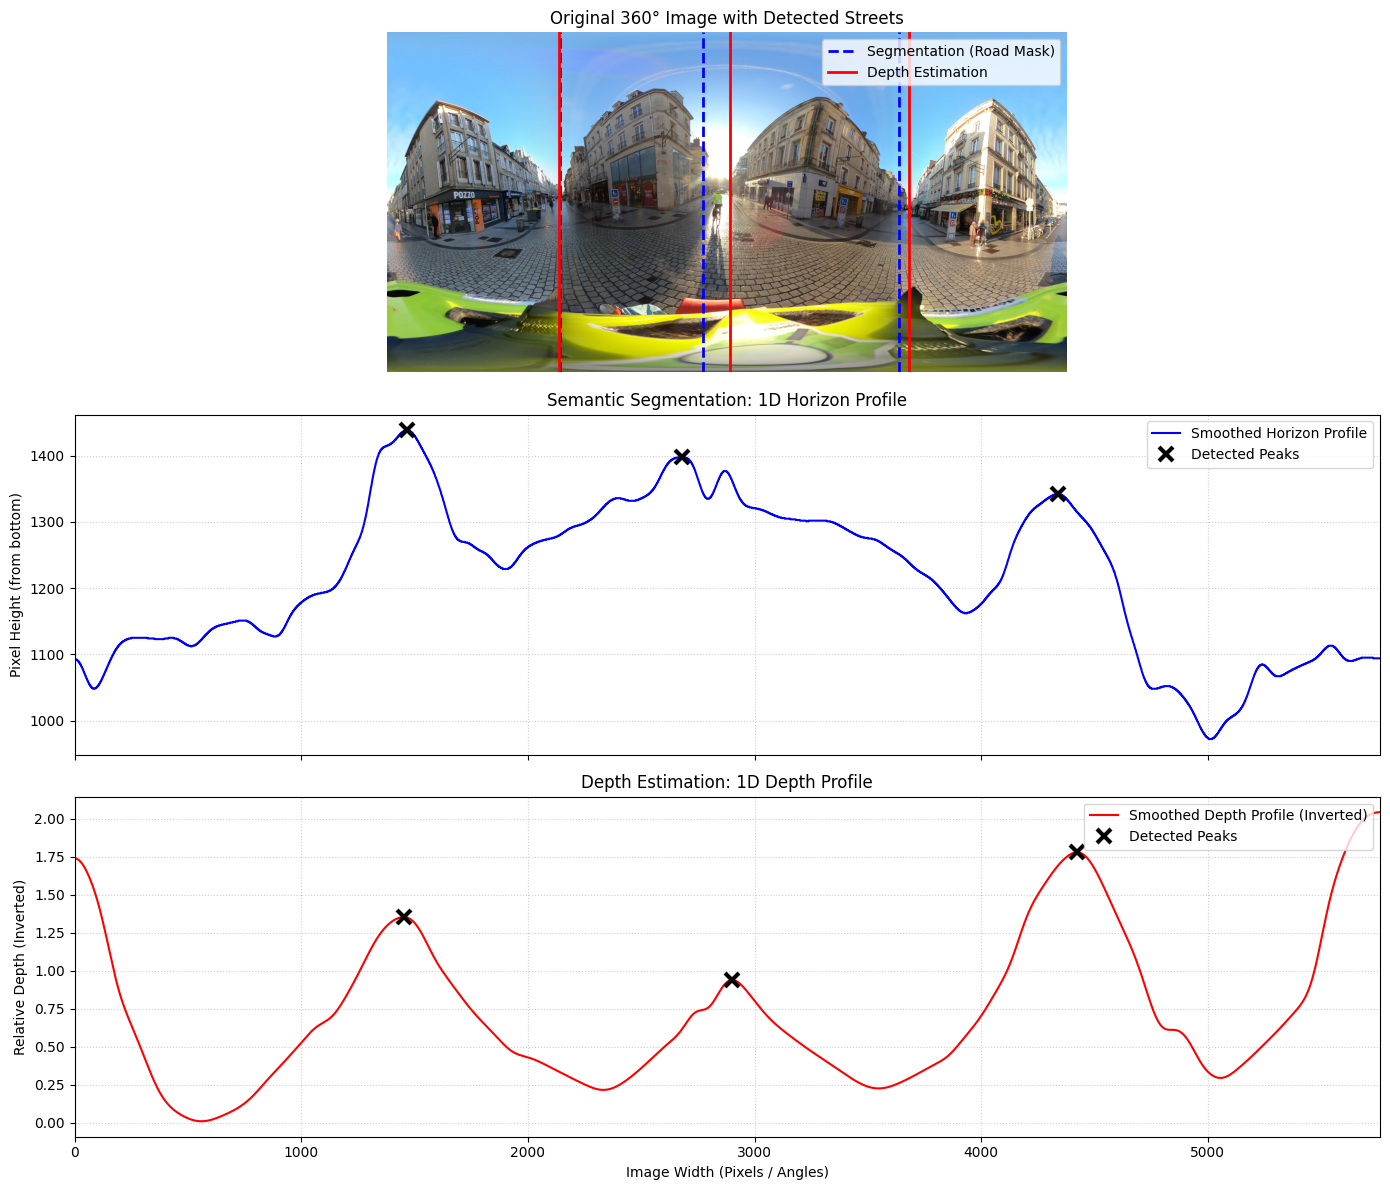

In [ ]:
panorama_path = "./streetview_panoramas/cc6b8656-d52e-42d1-ab10-542588c9f9f0.jpg"
image = cv2.imread(panorama_path)
seg_mask = segmentation_model.predict(image)
depth_map = depth_model.predict(image)
compare_street_detection(image, seg_mask, depth_map)

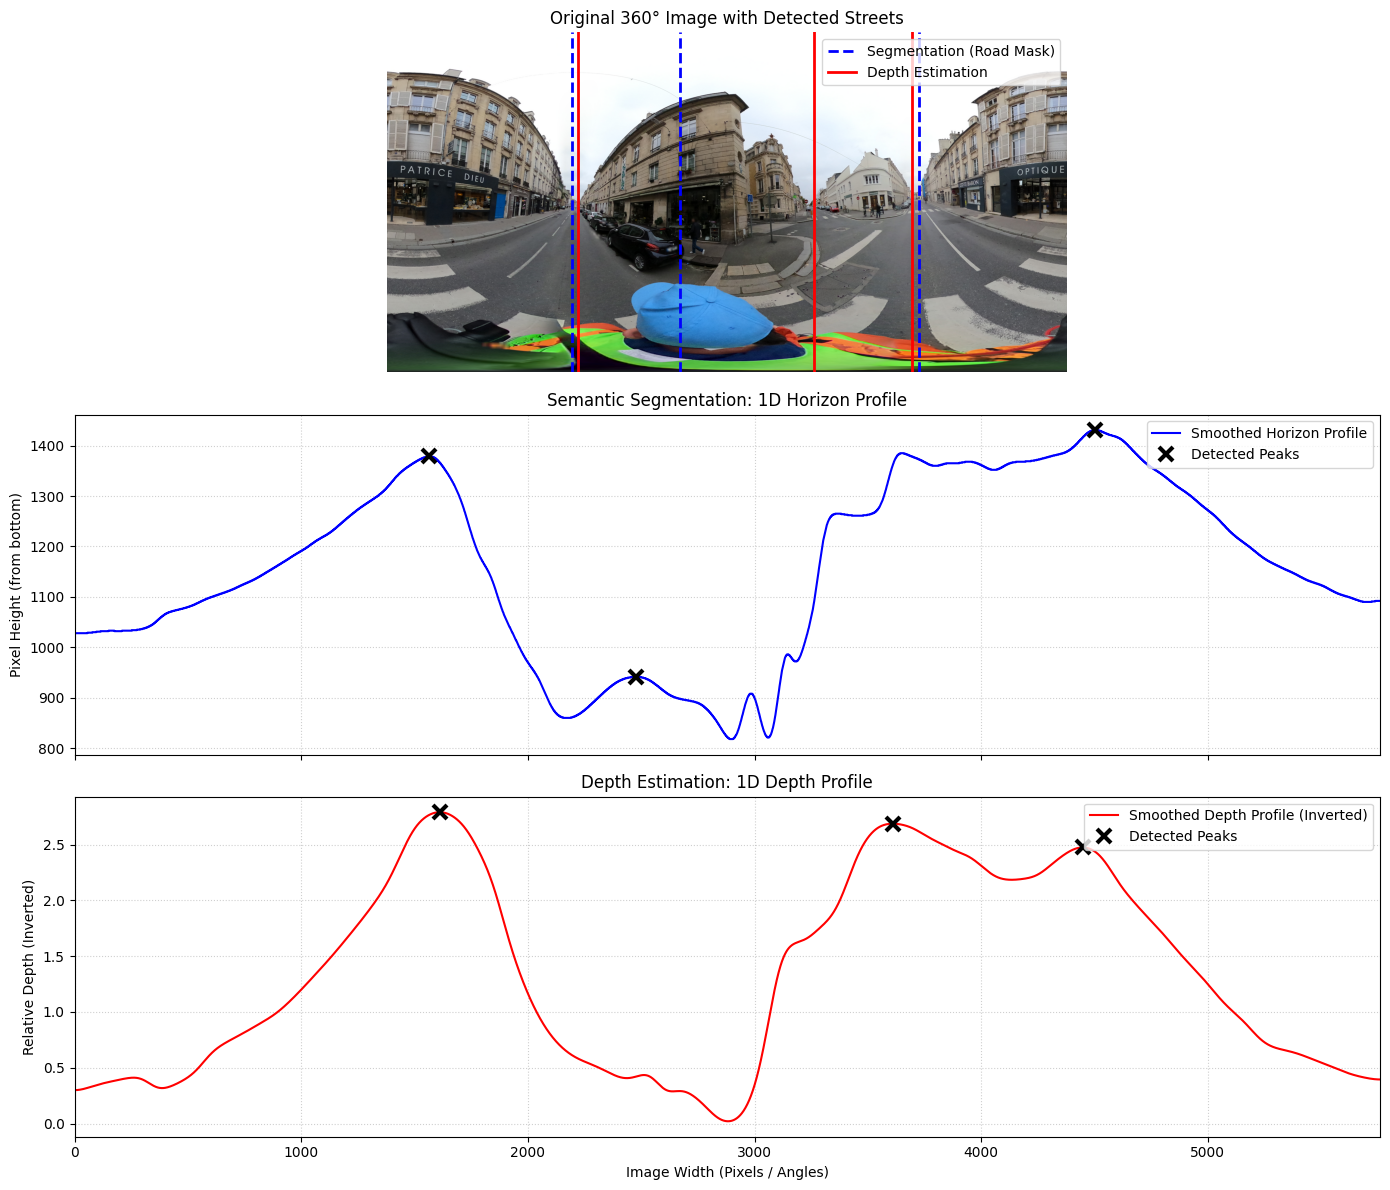

In [ ]:
panorama_path = "./streetview_panoramas/9e56e68c-937e-4d55-8e4b-db6e84e3beb0.jpg"
image = cv2.imread(panorama_path)
seg_mask = segmentation_model.predict(image)
depth_map = depth_model.predict(image)
compare_street_detection(image, seg_mask, depth_map)

- depth estimation works better